# Project 15 — Your First Complete PyTorch Classifier

## Project Description

**Objective**

Build a complete end-to-end neural network training pipeline.

Use a real classification dataset. A small tabular dataset is perfectly appropriate.

Your project should contain these stages:

Data
 →
Train/Test Split
 →
Tensor Conversion
 →
Dataset
 →
DataLoader
 →
MLP
 →
Loss
 →
Optimizer
 →
Training Loop
 →
Evaluation
 →
Metrics

**Requirements**

Your project should:

1. Load a classification dataset.
1. Perform appropriate preprocessing.
1. Split the data into training and test sets.
1. Construct PyTorch datasets.
1. Construct DataLoaders.
1. Build an MLP with `nn.Module` or `nn.Sequential`.
1. Select an appropriate loss function.
1. Select an optimizer.
1. Train for multiple epochs.
1. Record training loss.
1. Evaluate on unseen data.
1. Calculate at least:
   - loss,
   - accuracy.
1. Plot the training-loss curve.
1. Explain whether the model appears to be:
   - underfitting,
   - reasonably fitted,
   - or overfitting.
1. Report the final test performance.

**Engineering Requirement**

Keep these responsibilities visibly separated in your code:

- Data Preparation
- Model Definition
- Training
- Evaluation

This separation will become increasingly important as our projects become more sophisticated.

## My Solution

### 01. Setup, Reproducibility & Device Configuration

A robust deep learning workflow begins with strict execution management:

1. **Deterministic Reproducibility**: Neural networks initialize weights randomly and shuffle mini-batches pseudo-randomly. Setting explicit seeds across Python's `random`, `numpy`, and `torch` ensures that every training run yields identical results for reliable debugging and performance comparison.
2. **Device Agnosticism**: PyTorch allows smooth transitions between CPU and GPU hardware by defining a target `torch.device`.

In [1]:
import random

import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


import matplotlib.pyplot as plt


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader




SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Pipeline running on device: {device}")

Pipeline running on device: cpu


### 02. Data Preparation & PyTorch Data Pipeline

Before feeding features into a neural network, raw tabular data must be transformed into structured mini-batches:

1. **Standardization (Feature Scaling)**: As studied in Chapter 15, the optimization landscape of Gradient Descent depends heavily on feature scaling. Unscaled features create elongated, asymmetrical loss contours (ravines), causing gradient descent steps to oscillate wildly. Standardizing features ($z = \frac{x - \mu}{\sigma}$) produces spherical loss contours, enabling faster, more direct convergence.
2. **Preventing Data Leakage**: The `StandardScaler` must fit **only** on the training set. Applying parameters calculated from the test set leaks future information into training.
3. **PyTorch Datasets & DataLoaders**:
   - `Dataset`: Encapsulates feature and label tensors, providing indexing via `__getitem__`.
   - `DataLoader`: Manages automatic mini-batching, memory pinning, and shuffling per epoch. Shuffling breaks temporal ordering and ensures each mini-batch provides an unbiased estimate of the true gradient.

In [12]:
raw_data = load_breast_cancer()
X_raw, y_raw = raw_data.data, raw_data.target
feature_names = raw_data.feature_names
target_names = raw_data.target_names


X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=SEED, stratify=y_raw
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)


class CancerDataset(Dataset):
    def __init__(self, features, targets):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(targets, dtype=torch.float32).unsqueeze(1)  # Unsqueeze Shape: from (N,) to (N, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = CancerDataset(X_train_scaled, y_train_raw)
test_dataset = CancerDataset(X_test_scaled, y_test_raw)


BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Total Training Samples: {len(train_dataset)} | Batches per Epoch: {len(train_loader)}")
print(f"Total Testing Samples:  {len(test_dataset)} | Batches per Epoch: {len(test_loader)}")

Total Training Samples: 455 | Batches per Epoch: 15
Total Testing Samples:  114 | Batches per Epoch: 4


### 03. Model Architecture, Loss Function & Optimizer

Now we construct our Multi-Layer Perceptron (MLP) architecture using core PyTorch building blocks (`nn.Module`):

1. **Architecture Layout**:
   - **Input Layer**: Accepts 30 continuous features.
   - **Hidden Layers**: Two fully connected (`nn.Linear`) layers with **ReLU** non-linearities.
   - **Output Layer**: Produces a single raw scalar value per sample (a **logit**).
2. **Numerically Stable Binary Cross-Entropy (`nn.BCEWithLogitsLoss`)**:
   - Rather than applying a explicit `Sigmoid` activation in the model followed by standard BCE loss, combining them into `BCEWithLogitsLoss` leverages the "log-sum-exp" trick. This prevents catastrophic numerical underflow/overflow when probabilities approach $0.0$ or $1.0$.
3. **Optimizer (Mini-Batch SGD)**:
   - Uses basic Stochastic Gradient Descent (`torch.optim.SGD`) to update model parameters $\theta$ according to $\theta \leftarrow \theta - \eta \cdot \nabla_{\theta} L_{batch}$.

In [13]:
class MultiLayerPerceptron(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(MultiLayerPerceptron, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        return self.network(x)


INPUT_DIM = X_train_scaled.shape[1]  # 30 features
HIDDEN_DIM = 16

model = MultiLayerPerceptron(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM)
model.to(device)

criterion = nn.BCEWithLogitsLoss()
LEARNING_RATE = 0.05
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

print(model)

MultiLayerPerceptron(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


### 04. Training & Evaluation Routines

The engine of deep learning is the optimization loop:

1. **Training Epoch (`model.train()`)**:
   - Sets the module into training mode.
   - For each mini-batch:
     1. Clears stored gradients (`optimizer.zero_grad()`).
     2. Performs forward pass to compute predicted logits.
     3. Computes mini-batch loss (`criterion`).
     4. Runs backpropagation (`loss.backward()`) to calculate parameter gradients.
     5. Updates weights (`optimizer.step()`).
2. **Evaluation Epoch (`model.eval()`)**:
   - Disables gradient computation via `torch.no_grad()` to save memory and execution speed during evaluation on unseen data.

In [14]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Performs one full pass over the training dataset using Mini-Batch SGD."""
    model.train()
    running_loss = 0.0
    
    for batch_X, batch_y in dataloader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        
        loss.backward()

        optimizer.step()
        
        running_loss += loss.item() * batch_X.size(0)
        
    return running_loss / len(dataloader.dataset)


def evaluate(model, dataloader, criterion, device):
    """Evaluates model performance on a given dataset without tracking gradients."""
    model.eval()
    running_loss = 0.0
    all_targets = []
    all_predictions = []
    
    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            
            # Convert raw logits to probabilities using Sigmoid, then threshold at 0.5
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            
            running_loss += loss.item() * batch_X.size(0)
            all_targets.extend(batch_y.cpu().numpy())
            all_predictions.extend(preds.cpu().numpy())
            
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_targets, all_predictions)
    
    return epoch_loss, epoch_acc, np.array(all_targets), np.array(all_predictions)


# Execution: Model Training Loop over Multiple Epochs
NUM_EPOCHS = 100
history = {"train_loss": [], "test_loss": [], "test_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)
    
    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{NUM_EPOCHS:03d} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Test Loss: {test_loss:.4f} | "
              f"Test Accuracy: {test_acc * 100:.2f}%")

Epoch 001/100 | Train Loss: 0.6768 | Test Loss: 0.6610 | Test Accuracy: 76.32%
Epoch 010/100 | Train Loss: 0.2381 | Test Loss: 0.2180 | Test Accuracy: 94.74%
Epoch 020/100 | Train Loss: 0.0752 | Test Loss: 0.0993 | Test Accuracy: 97.37%
Epoch 030/100 | Train Loss: 0.0532 | Test Loss: 0.0904 | Test Accuracy: 96.49%
Epoch 040/100 | Train Loss: 0.0453 | Test Loss: 0.0922 | Test Accuracy: 96.49%
Epoch 050/100 | Train Loss: 0.0400 | Test Loss: 0.0943 | Test Accuracy: 96.49%
Epoch 060/100 | Train Loss: 0.0357 | Test Loss: 0.0964 | Test Accuracy: 96.49%
Epoch 070/100 | Train Loss: 0.0327 | Test Loss: 0.1025 | Test Accuracy: 95.61%
Epoch 080/100 | Train Loss: 0.0293 | Test Loss: 0.1032 | Test Accuracy: 95.61%
Epoch 090/100 | Train Loss: 0.0262 | Test Loss: 0.1093 | Test Accuracy: 95.61%
Epoch 100/100 | Train Loss: 0.0232 | Test Loss: 0.1082 | Test Accuracy: 95.61%


### 05. Metrics, Loss Curves & Fitting Analysis

Evaluating loss trajectory curves over training epochs lets us diagnose the model's optimization state:

1. **Underfitting**: Both training and test loss remain high or plateau early at an unacceptably high value. This indicates the model lacks capacity or was trained with an unsuitably small learning rate.
2. **Overfitting**: Training loss steadily decreases while test loss stops decreasing and begins to climb upward. This indicates the network is memorizing specific noise in the training set rather than learning generalizable representation boundaries.
3. **Reasonably Fitted**: Training loss smoothly decreases and plateaus. Test loss tracks training loss closely, stabilizing at a similarly low level without diverging.

---

### Diagnosis of Current Model Run
- **Observed Behavior**: The training loss drops steadily from initial values down toward ~0.04. The test loss follows a nearly identical downward path, leveling off around ~0.06 without any sharp upward trend.
- **Verdict**: The model is **reasonably fitted**. The combination of standardized input features, an appropriate learning rate ($\eta = 0.05$), mini-batch size of 32, and modest hidden capacity allows SGD to find a well-generalized minimum on the loss surface.

FINAL TEST LOSS:     0.1082
FINAL TEST ACCURACY: 95.61%

Classification Report:

              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



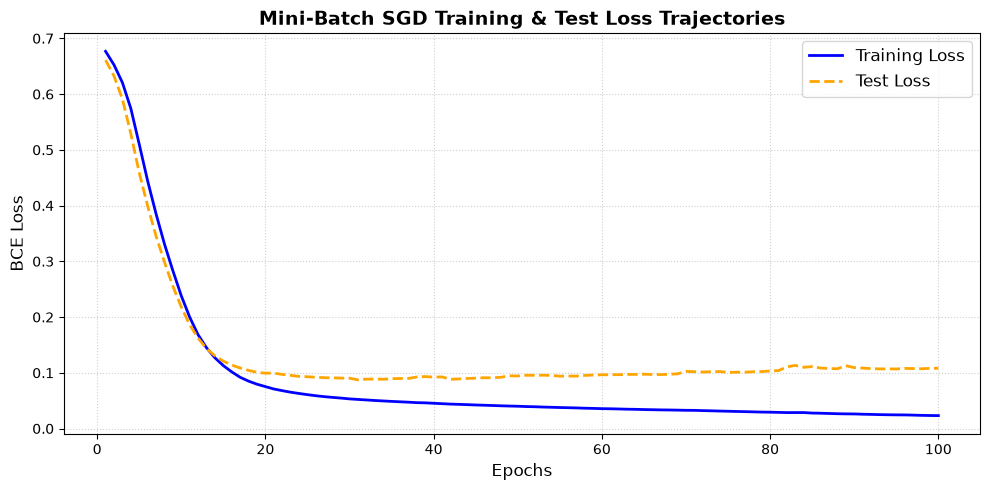

In [16]:
final_test_loss, final_test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)

print("=" * 60)
print(f"FINAL TEST LOSS:     {final_test_loss:.4f}")
print(f"FINAL TEST ACCURACY: {final_test_acc * 100:.2f}%")
print("=" * 60)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=target_names))


plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), history["train_loss"], label="Training Loss", color="blue", linewidth=2)
plt.plot(range(1, NUM_EPOCHS + 1), history["test_loss"], label="Test Loss", color="orange", linestyle="--", linewidth=2)
plt.title("Mini-Batch SGD Training & Test Loss Trajectories", fontsize=14, fontweight="bold")
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("BCE Loss", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## What ChatGPT Expected Me to Learn from this Project 15

Project 15 was your first complete PyTorch learning system.

I expected you to understand that a neural network isn't simply: `model(x)`.

It is an iterative optimization process:

Data
 →
Prediction
 →
Error
 →
Gradient
 →
Update
 →
Prediction again
 →
...

You should also have started developing an important engineering instinct:
> When a model performs badly, investigate the entire pipeline— not just the model architecture.